# 2. Pretrain the disk template (spatial-mode initialization)

Fitting sparse EHT visibilities from a random initialization is badly non-convex: with ≤ 42
visibilities per frame there are many spurious minima, and the spatial modes that come out of a
cold start are high-frequency garbage that happens to fit the data. The new NeuralDMD pipeline
therefore **warm-starts the spatial network** before touching any visibility data:

1. estimate the source's size from the data — here the flux-weighted **radius of gyration**
   of the (resized) ground-truth movie; for real data you would estimate the extent from the
   visibility-amplitude fall-off;
2. build a bank of **complex Zernike modes** on a disk of that size, orthonormalized on the
   pixel grid (masked QR), and keep a low-azimuthal-order subset — rings (m=0) and low-m
   asymmetries are the right vocabulary for ring + hot spot scenes;
3. train the spatial network so its gauge-fixed modes `[W0, W]` match the Zernike targets up
   to a per-mode complex scale (a scale-invariant alignment loss).

Two properties make this cheap and reusable:

- the alignment loss depends **only on the spatial network** — the temporal nets receive no
  gradient, so the saved template is purely a spatial-mode initialization;
- the template depends only on grid size, disk radius, and model hyperparameters — one
  template can be reused across datasets with a similar source extent.

**Environment**: JAX (+ equinox, optax). GPU recommended but not required
(~1–2 min on a laptop GPU, ~10 min on CPU).

In [2]:
import os
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from neuraldmd import NeuralDMD
from neuraldmd.zernike import build_zernike_targets, plot_mode_bank
from neuraldmd.pretraining import radius_of_gyration, pretrain_model, save_template
from neuraldmd.evaluation import load_hdf5

obs_dir = "./data/EHT2017_cp/mring+hs_f0.04_resizedobs"
models_dir = "./models"

# The network's coordinates are *normalized* units (nominal fov = pi); the
# physical angular scale lives entirely inside the forward operators A.
fov = np.pi

r = 10               # number of complex dynamic modes
num_frequencies = 2  # positional-encoding octaves (low: smooth images)

## Disk radius from the data

`R_disk = 1.5 × R_g` comfortably covers the ring + hot spot orbit.

In [3]:
frames, times = load_hdf5(obs_dir, "gt_video_resized.hdf5")
height, width = frames.shape[1:]

Rg, dRg = radius_of_gyration(frames, fov_x=fov, fov_y=fov)
R_disk = 1.5 * Rg
print(f"frames {frames.shape},  R_g = {Rg:.3f},  R_disk = {R_disk:.3f}  (fov = {fov:.3f})")

frames (411, 50, 50),  R_g = 0.462,  R_disk = 0.692  (fov = 3.142)


## Zernike targets

We build `r + 1` targets: column 0 (the n=0, m=0 disk) initializes the **static mode** `W0`,
and the remaining `r` columns initialize the complex dynamic modes `W`.

targets: (2500, 11)   (n, m) picked: [(0, 0), (2, 0), (4, 0), (6, 0), (8, 0), (1, -1), (1, 1), (3, -1), (3, 1), (5, -1), (5, 1)]


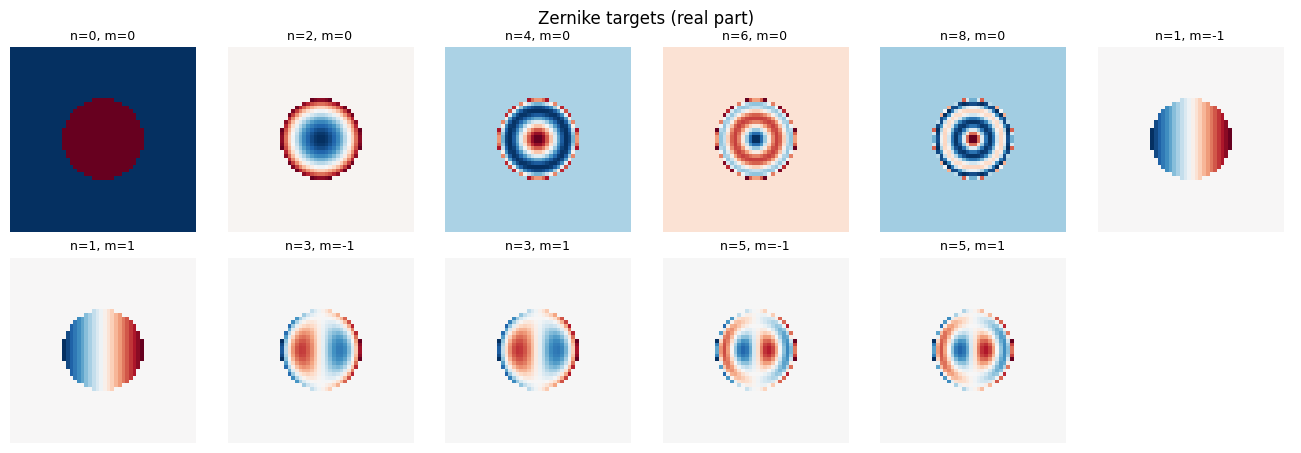

In [4]:
Z_targets, picked, mask, xy = build_zernike_targets(
    height, width, R_disk, fov, fov, r + 1, max_n=8, prefer_ms=(0, 1, 2, 3),
)
print("targets:", Z_targets.shape, "  (n, m) picked:", picked)

fig = plot_mode_bank(Z_targets, [f"n={n}, m={m}" for n, m in picked], height, width, which="real")
fig.suptitle("Zernike targets (real part)", y=1.02);

## Align the spatial network

 10%|▉         | 199/2000 [00:12<00:36, 49.12it/s, loss=5.6154] 

step 200/2000  alignment loss 5.61542


 20%|██        | 400/2000 [00:16<00:32, 49.43it/s, loss=3.1232]

step 400/2000  alignment loss 3.12318


 30%|██▉       | 599/2000 [00:20<00:29, 47.99it/s, loss=2.4974]

...

 90%|████████▉ | 1799/2000 [00:44<00:04, 46.63it/s, loss=1.5006]

step 1800/2000  alignment loss 1.50062


100%|█████████▉| 1999/2000 [00:49<00:00, 51.13it/s, loss=1.4641]

step 2000/2000  alignment loss 1.46409


100%|██████████| 2000/2000 [00:49<00:00, 40.80it/s, loss=1.4641]


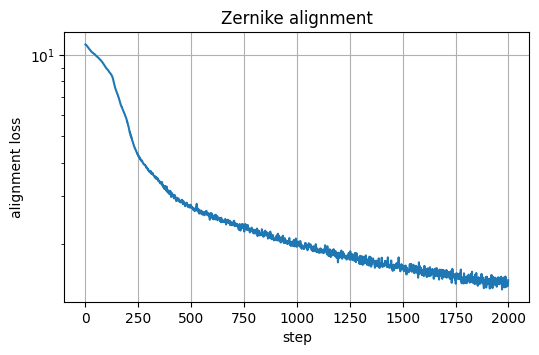

In [5]:
key = jax.random.PRNGKey(42)
model = NeuralDMD(r, key=key, num_frequencies=num_frequencies)

model, losses = pretrain_model(model, xy, Z_targets, num_steps=2000, lr=1e-4, key=key)

plt.figure(figsize=(6, 3.5))
plt.plot(losses)
plt.xlabel("step"); plt.ylabel("alignment loss"); plt.yscale("log"); plt.grid(True)
plt.title("Zernike alignment"); plt.show()

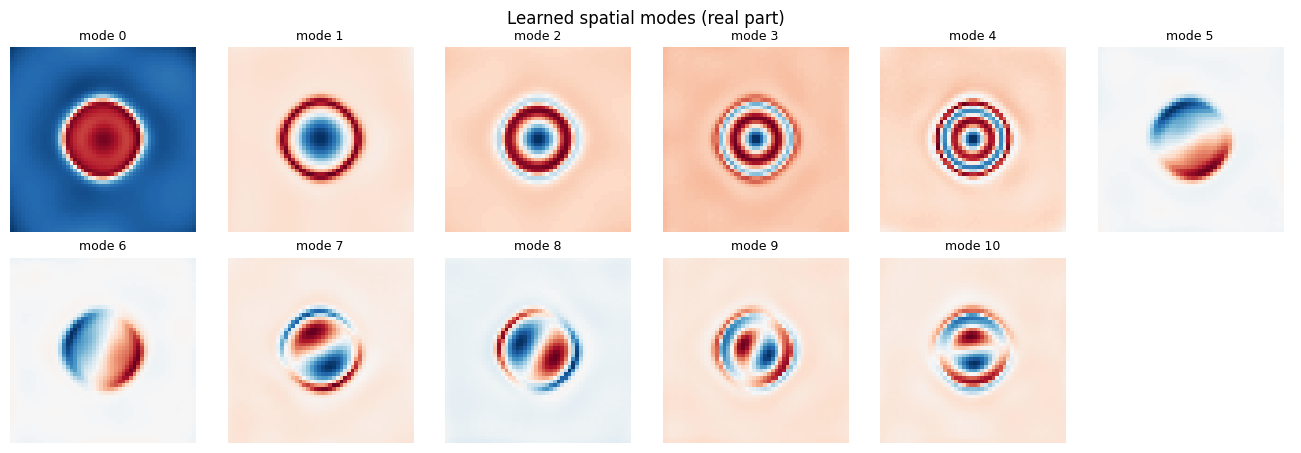

In [6]:
# the spatial modes after pretraining (gauge-fixed), next to their targets
W0, W, Omega, b0, b = model(jnp.asarray(xy))
learned = np.concatenate([np.asarray(W0), np.asarray(W)], axis=1)
fig = plot_mode_bank(learned, [f"mode {k}" for k in range(learned.shape[1])], height, width, which="real")
fig.suptitle("Learned spatial modes (real part)", y=1.02);

In [7]:
template_path = save_template(model, models_dir)

Saved disk template to ./models/disk_template_r10_f2.eqx


**Next:** [`03_train.ipynb`](03_train.ipynb) — train on the visibilities, starting from this
template.